In this notebook we explore Gaussian Processes for processing ESR data. Previous studies have demonstrated that GPs can achieve better than 1 K accuracy in spectra -> temperature mapping


In [1]:
# import modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show, grid, tight_layout
import datetime
from sklearn.model_selection import train_test_split
# Make the Jupyter Notebook fill 90 percent of the screen (nerd_mode)
from IPython.display import display, HTML
display(HTML("<style>:root { --jp-notebook-max-width: 90% !important; }</style>"))

# Gaussian Processes
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.preprocessing import MinMaxScaler
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

Index(['Unnamed: 0', 'frequency', '25up', '30up', '35up', '40down', '45down',
       '50', '45', '40', '35', '30', '25', '20'],
      dtype='object')


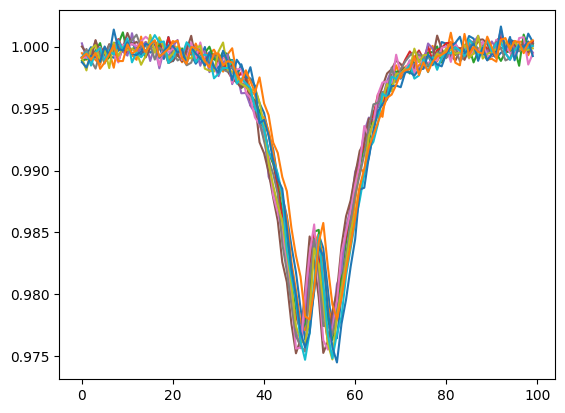

In [2]:
# load data and preprocess it 

temps_ = ['25', '30', '35',
       '40', '45', '50', '45', '40', '35', '30', '25', '20']
temps = np.array(temps_, dtype=float)

temps
## import data file
fpath = '../../esr_data/saved_data/cycle1'

df_= pd.read_csv(fpath, sep=',', header = 0); 
df= df_.iloc[0:, :-1]
df.drop(columns= ['25 C-lower power', '15', '10', '10.1', '-30', "-20"], inplace= True)
print(df.columns)
df.iloc[:, 2:].plot(legend= False)

# define and scale the frequency axis 
x_esr = df.frequency.values
y_esr = df.iloc[:, 2:]

#scale x axis to 0-100
sc = MinMaxScaler()
x_scale = sc.fit_transform(x_esr.reshape(-1, 1)).flatten()*100



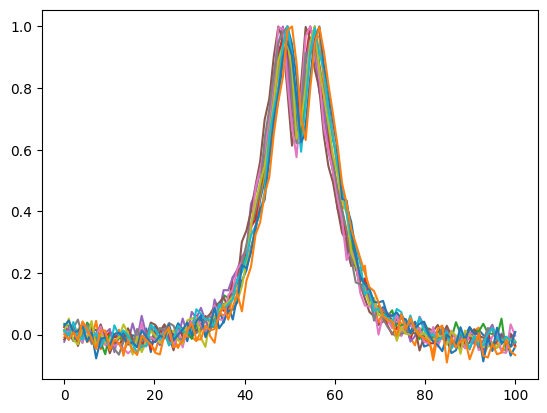

In [3]:
# plot baseline subtracted  y data
y_esr = y_esr.apply(lambda x: x - x[:10].mean())#+0.01
y_esr = -1*y_esr
y_esr = y_esr.apply(lambda x: x/x.max())
plt.plot(x_scale, y_esr);
#plt.xlim(40, 80)

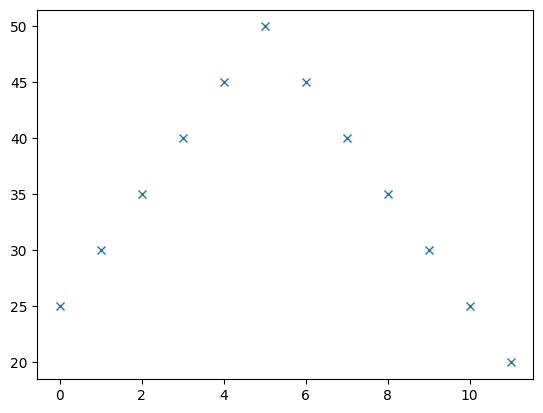

In [4]:
plt.plot(temps, 'x')

In [5]:
X_train, X_test, y_train, y_test = y_esr.iloc[:, 0:6].T, y_esr.iloc[:, 6:].T, temps[:6], temps[6:]

#train_test_split(y_esr.T, temps, test_size=0.5)

In [6]:

# Define GP kernel
kernel = ConstantKernel(1.0) * (Matern(length_scale=0.2, nu=1.5, length_scale_bounds=(0.05, 1.0)) \
        + ConstantKernel(1.0) * Matern(length_scale=5, nu=2.5, length_scale_bounds=(1, 10))) + WhiteKernel()
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y=False,
    n_restarts_optimizer=5
)
    

In [7]:
### Fit GP to map spectral features onto temperature

gp.fit(X_train, y_train)

# Predict mean and std
mu, std = gp.predict(X_test, return_std=True)
mu = mu.flatten()
std = std.flatten()



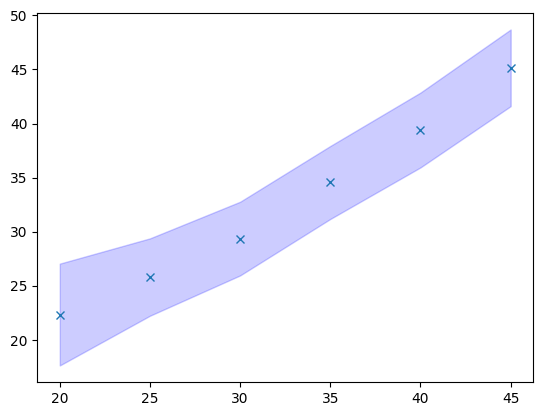

In [8]:
plt.plot(y_test, mu, 'x')
plt.fill_between(y_test, mu - std, mu + std, alpha=0.2, color = 'blue')

In [9]:
np.mean(std)

np.float64(3.677927657923565)

Flip training vs testing ramps

In [11]:

X_train, X_test, y_train, y_test =  y_esr.iloc[:, 6:].T, y_esr.iloc[:, 0:6].T, temps[6:], temps[:6]
    

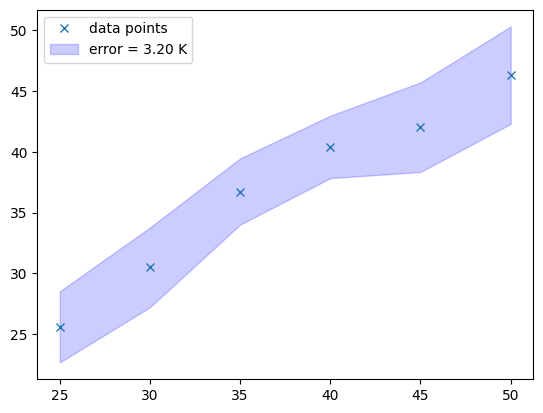

In [18]:

# Define GP kernel
kernel = ConstantKernel(1.0) * (Matern(length_scale=0.2, nu=1.5, length_scale_bounds=(0.05, 1.0)) \
        + ConstantKernel(1.0) * Matern(length_scale=5, nu=2.5, length_scale_bounds=(1, 10))) + WhiteKernel()
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y=False,
    n_restarts_optimizer=5
)

### Fit GP to map spectral features onto temperature

gp.fit(X_train, y_train)

# Predict mean and std
mu, std = gp.predict(X_test, return_std=True)
mu = mu.flatten()
std = std.flatten()

plt.plot(y_test, mu, 'x')
plt.fill_between(y_test, mu - std, mu + std, alpha=0.2, color = 'blue')
plt.legend(['data points', f'error = {np.mean(std):.2f} K'])